In [32]:
import skimage as skim
import sklearn 
import cv2
import numpy as np
import os
import csv

import matplotlib.pyplot as plt
from PIL import Image
from tqdm import tqdm
import napari
%load_ext autoreload
%autoreload 2
import _utils

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


### Open references and references annotated

Code below open both references and references annotated and put it in a table.

In [118]:
# table with name of chocolate
chocolates = {
    0: 'amandina',
    1: 'arabia',
    2: 'comtesse',
    3: 'creme_brulee',
    4: 'jelly_black',
    5: 'jelly_milk',
    6: 'jelly_white',
    7: 'noblesse',
    8: 'noir_authentique',
    9: 'passion_au_lait',
    10: 'stracciatella',
    11: 'tentation_noir',
    12: 'triangolo'
}

# directory paths
ref_path = '../data/chocolate-recognition-classic/references/'
ref_path_annotated = '../data/dataset_project_iapr2025/references_annotated/'
# full path and load images
ref_choco = []
ref_choco_annotated = []
for filename in tqdm(os.listdir(ref_path)): # reference images
    full_path = os.path.join(ref_path, filename)
    if os.path.isfile(full_path):
        img = np.array(Image.open(full_path))
        binned_ref = _utils.median_bin_rgb(img, block_size=(10, 10))
        ref_choco.append(binned_ref)

for filename in tqdm(os.listdir(ref_path_annotated)): # reference annotated images
    full_path = os.path.join(ref_path_annotated, filename)
    if os.path.isfile(full_path):
        img = np.array(Image.open(full_path))
        binned_ref_annotated = skim.measure.block_reduce(img, block_size=(10, 10), func=np.median)
        N, M = binned_ref_annotated.shape
        for j in range(N):
            for k in range(M):
                if binned_ref_annotated[j][k] != 0:
                    binned_ref_annotated[j][k] = 1
                else:
                    binned_ref_annotated[j][k] = 0
        ref_choco_annotated.append(binned_ref_annotated)

100%|██████████| 13/13 [00:02<00:00,  4.34it/s]


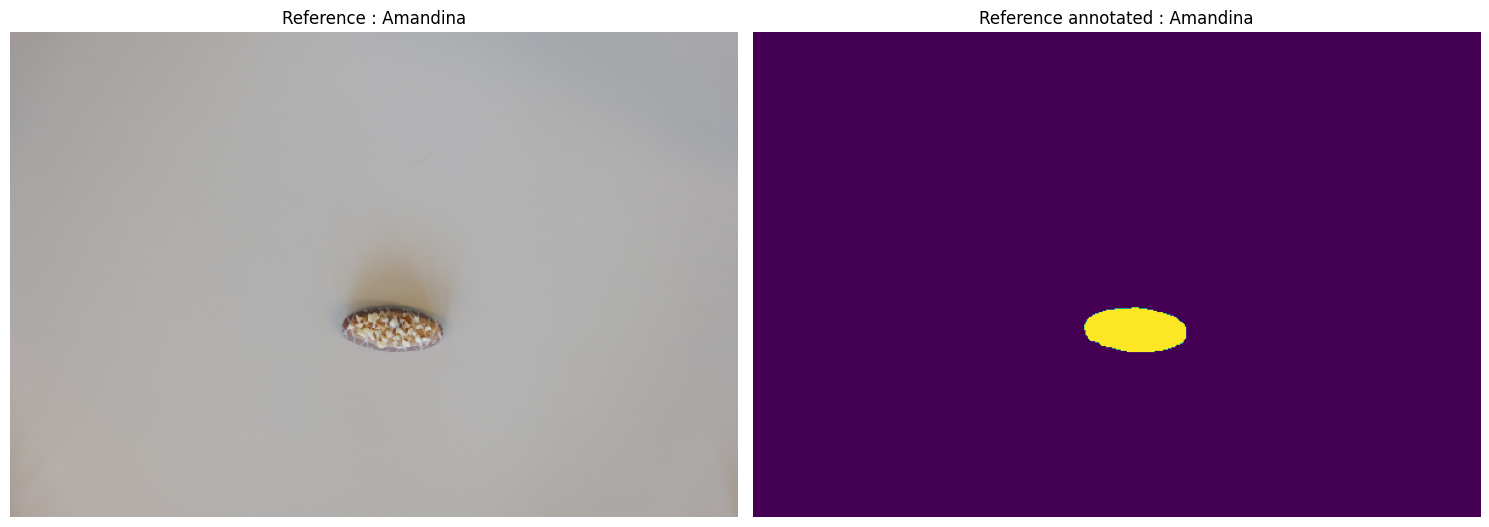

In [119]:
plt.figure(figsize=(15, 7))
plt.subplot(1, 2, 1)
plt.title('Reference : Amandina')
plt.imshow(ref_choco[0])
plt.axis('off')
plt.subplot(1, 2, 2)
plt.title('Reference annotated : Amandina')
plt.imshow(ref_choco_annotated[0])
plt.axis('off')
plt.tight_layout()
plt.show()

Above an example of a reference and its binary image. We compute by hand the contour to have the most perfect form for all the chocolates. Thus, we have a good reference for each chocolate.

### Open an raw image to use as example

In [222]:
# Open raw image
example = np.array(Image.open('../data/chocolate-recognition-classic/test/L1000767.JPG'))
example = _utils.median_bin_rgb(example, block_size=(10, 10))

# create a mask with super-pixels
binned_bgr = cv2.cvtColor(example, cv2.COLOR_RGB2BGR)
binned_hsv = cv2.cvtColor(binned_bgr, cv2.COLOR_BGR2HSV)
spx = skim.segmentation.slic(example, n_segments=5000, compactness=.1, sigma=1, start_label=0)
hsv_feat = _utils.hsv_spx_feat(binned_hsv, spx, np.median)
gmm = _utils.gmm_on_spx_fit(range(1,15), hsv_feat)
labels = _utils.gmm_on_spx_predict(gmm, hsv_feat[spx], spx)

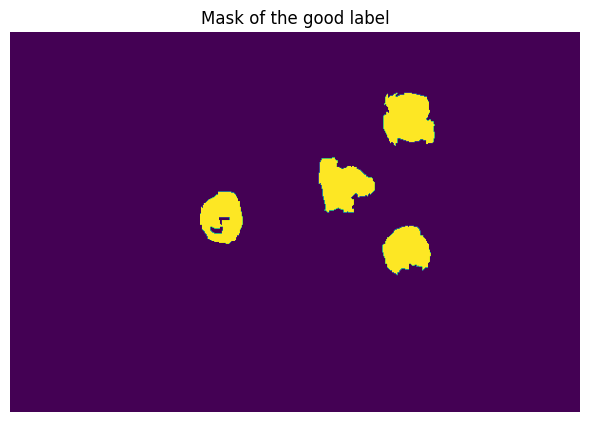

In [226]:
# choose good label
chosen_label = (labels == 5) # Manually change this number because it depending on the gmm learning
plt.figure(figsize=(6, 6))
plt.title('Mask of the good label')
plt.imshow(chosen_label)
plt.axis('off')
plt.tight_layout()
plt.show()

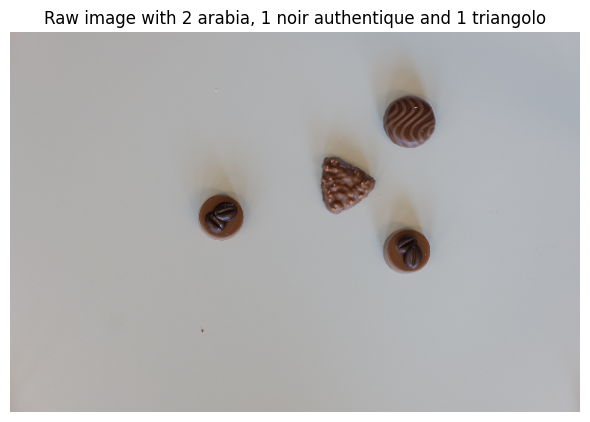

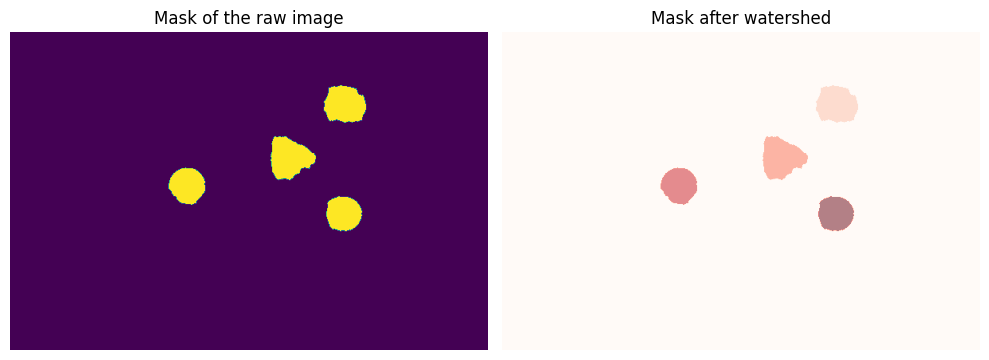

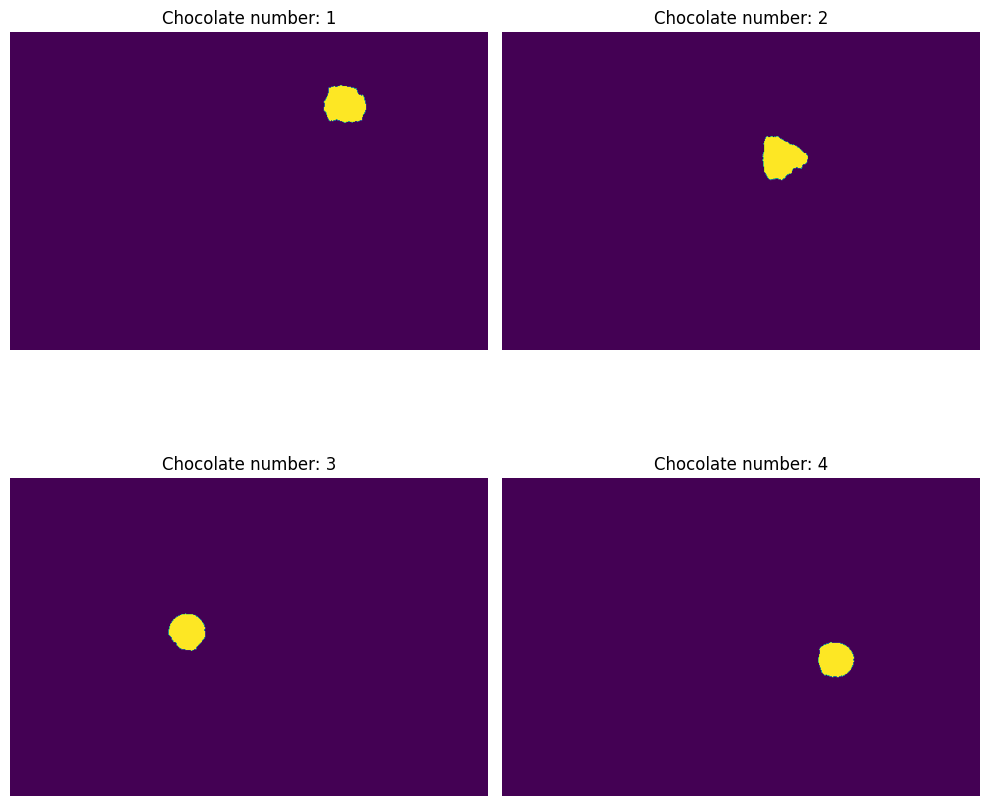

In [227]:
# apply region growing
mask = _utils.region_growing(example, binned_hsv, chosen_label)

# apply Watershed algorithm
labeled_image = _utils.watershed(mask)

# plot the image, the mask and the mask after the watershed
plt.figure(figsize=(6, 6))
plt.title('Raw image with 2 arabia, 1 noir authentique and 1 triangolo')
plt.imshow(example)
plt.axis('off')
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 10))

plt.subplot(1, 2, 1)
plt.title('Mask of the raw image')
plt.imshow(mask)
plt.axis('off')

plt.subplot(1, 2, 2)
plt.title('Mask after watershed')
plt.imshow(labeled_image, alpha=0.5, cmap='Reds')
plt.axis('off')

plt.tight_layout()

plt.show()

# plot each chocolate in order to assign a true label
plt.figure(figsize=(10, 10))
for i in range(4):
    plt.subplot(2, 2, i+1)
    plt.title(f'Chocolate number: {i+1}')
    plt.imshow((labeled_image == i+1))
    plt.axis('off')

plt.tight_layout()

plt.show()

Here an example of one image with four chocolates on it. We can see the mask after the processing of the image to extract features. We will use this example to show how the classification works.

We also have the four chocolate masks in order and can now make a tabel with true label for each of them

In [228]:
# table with name of true chocolates in the image
true_chocolates = ['noir_authentique', 'triangolo', 'arabia', 'arabia']

# Classification

In this part, the goal is to detect all the chocolates in one image and to classify it with the gived references. To do this, we will use the mask create in the previous part to classify all the chocolate and extract features of the references and the objects to finally classify it.

### Extraction of features

First step is to extract both references and objects features. We extract the contours, the image with only the references/objects in RGB, the number of pixels not equal at zero in the image and the rectangularity. This is made for all the reference and for the image we analyse.

In [229]:
# Features references
contours_ref, choco, f_rect_ref, sum_choc_annotated = _utils.features_ref(len(ref_choco), ref_choco_annotated, ref_choco)

# Features objects
contours_object, diff_object, f_rect, array_sum = _utils.features_objects(np.max(labeled_image), labeled_image, example)

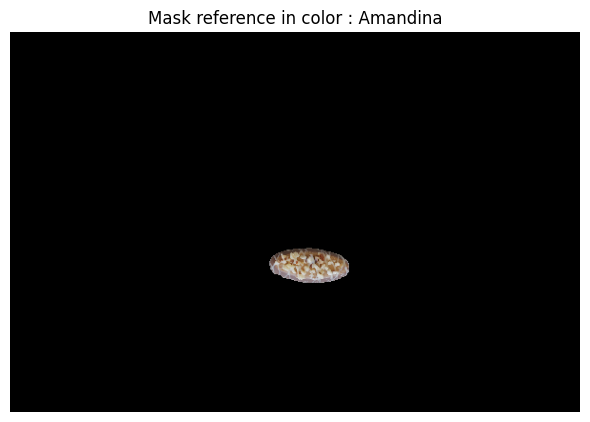

C:\Users\mikae\AppData\Local\Temp\ipykernel_22188\2861059937.py:8: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('tab20', 17)


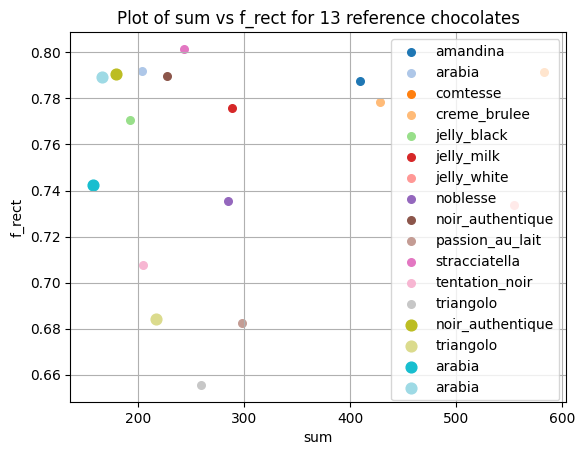

In [230]:
plt.figure(figsize=(6, 6))
plt.title('Mask reference in color : Amandina')
plt.imshow(choco[0])
plt.axis('off')
plt.tight_layout()
plt.show()

colors = plt.cm.get_cmap('tab20', 17)
for i in range(len(ref_choco_annotated)):
    plt.scatter(sum_choc_annotated[i], f_rect_ref[i], color=colors(i), label=chocolates[i], s=30)  # reference points, smaller
for i in range(len(diff_object)):
    plt.scatter(array_sum[i], f_rect[i], color=colors(i+13), label=true_chocolates[i], s=60)  # detected objects, bigger
plt.xlabel('sum')
plt.ylabel('f_rect')
plt.title('Plot of sum vs f_rect for 13 reference chocolates')
plt.legend()
plt.grid(True)
plt.show()

The graph above show a first look at how we proceed for the classification. We calcule the sum of all the pixels of the object and divide by the number of non-zero pixel to have a mean. We also calcul the rectangularity of the object. By comparing theses values with the references by making a treshold on the reference value, we can assign a chocolate type to the object. We can observe that due to the filter, the form of the detected chocolate are not perfect. Hence, the chocolates are close but not close enough to their reference to properly classify them. In this example, if we classify our chocolates with a threshold on both criterion, it will lead to false negatives. So We have to add one more criterion to better classify them and have less false positives or false negatives.

### Fourier descriptors

The third criterion we will add is the fourier descriptor. We will compare the reference with the object and choose the nearest reference as detected chocolate.

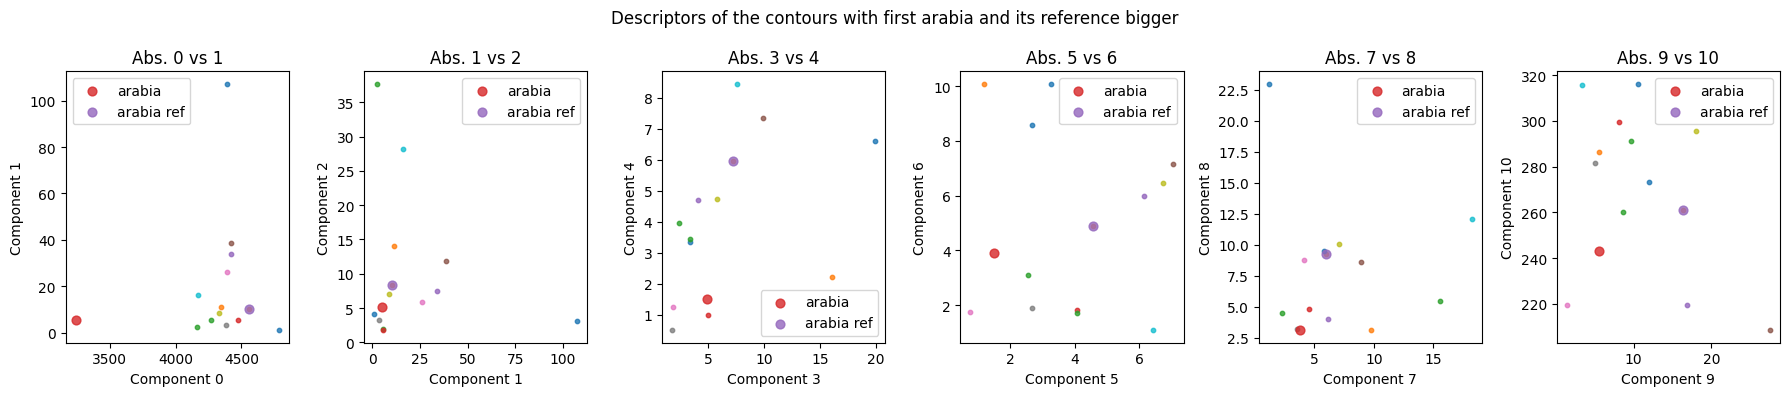

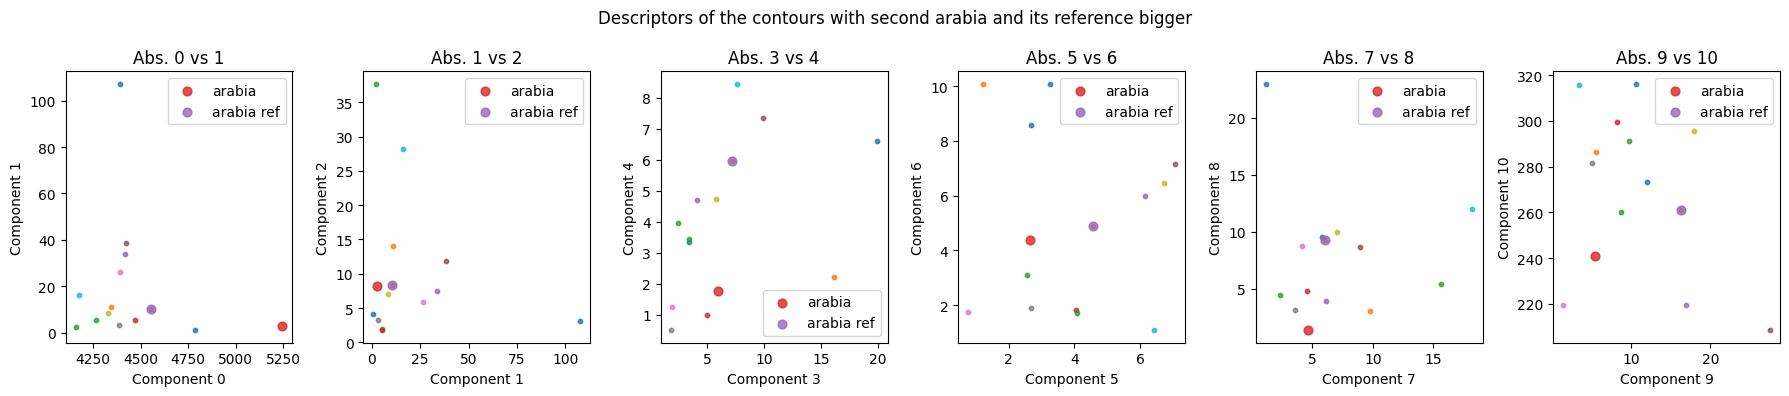

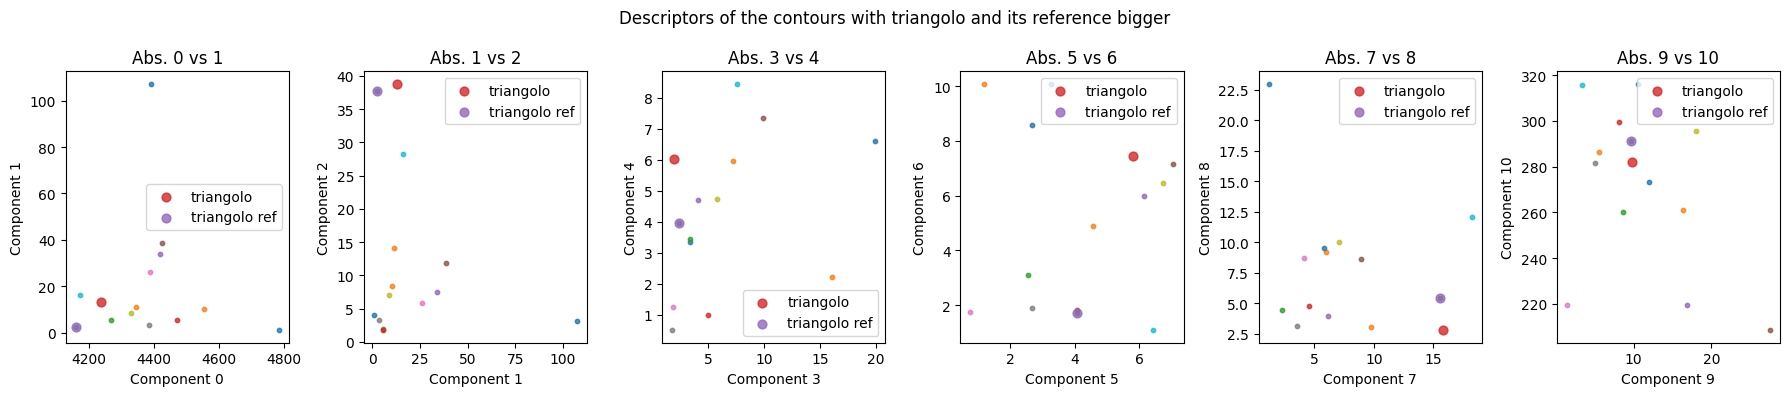

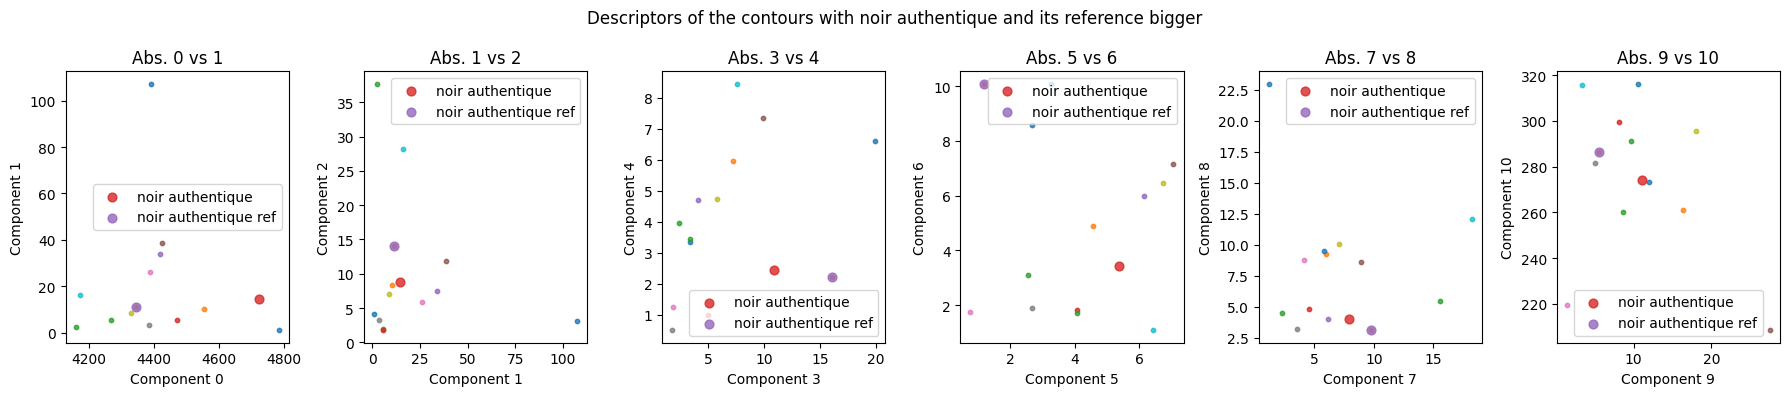

In [231]:
# Fourier descriptors
N = len(contours_ref)
n_samples = 11

contours_inter_ref = _utils.interpolation(contours_ref, n_samples)
descriptors_ref = _utils.compute_descriptor(contours_inter_ref, n_samples)

contours_inter_object = _utils.interpolation(contours_object, n_samples)
descriptors_object = _utils.compute_descriptor(contours_inter_object, n_samples)

# Plot features (plot 4 times to see each detected chocolate with its true reference)

# First plot
# Number of paris to display
n_features = descriptors_ref.shape[1]
# Define pairs for 2D plots
pairs = np.array(range(2*np.ceil(n_features / 2).astype(int)))
# Check if odd lenght, shift second feature to have pairs
if n_features % 2 == 1:
    pairs[2:] = pairs[1:-1]
# Convert to 2d array
pairs = pairs.reshape(-1, 2)

# Plot each pairs and labels
n_plots = len(pairs)
_ , axes = plt.subplots(1, n_plots, figsize=(18, 4))

for i, (pa, pb) in enumerate(pairs):
    # Abs
    for n in range(len(ref_choco)):
        axes[i].scatter(np.abs(descriptors_ref[n, pa]), np.abs(descriptors_ref[n, pb]), s=10, alpha=0.8)
    axes[i].scatter(np.abs(descriptors_object[2, pa]), np.abs(descriptors_object[2, pb]), s=40, alpha=0.8, label='arabia')
    axes[i].scatter(np.abs(descriptors_ref[1, pa]), np.abs(descriptors_ref[1, pb]), s=40, alpha=0.8, label='arabia ref')
    axes[i].set_xlabel("Component {}".format(pa))
    axes[i].set_ylabel("Component {}".format(pb))
    axes[i].set_title("Abs. {} vs {}".format(pa, pb))
    axes[i].legend()

plt.suptitle("Descriptors of the contours with first arabia and its reference bigger")
plt.tight_layout()

# Second plot
# Number of paris to display
n_features = descriptors_ref.shape[1]
# Define pairs for 2D plots
pairs = np.array(range(2*np.ceil(n_features / 2).astype(int)))
# Check if odd lenght, shift second feature to have pairs
if n_features % 2 == 1:
    pairs[2:] = pairs[1:-1]
# Convert to 2d array
pairs = pairs.reshape(-1, 2)

# Plot each pairs and labels
n_plots = len(pairs)
_ , axes = plt.subplots(1, n_plots, figsize=(18, 4))

for i, (pa, pb) in enumerate(pairs):
    # Abs
    for n in range(len(ref_choco)):
        axes[i].scatter(np.abs(descriptors_ref[n, pa]), np.abs(descriptors_ref[n, pb]), s=10, alpha=0.8)
    axes[i].scatter(np.abs(descriptors_object[3, pa]), np.abs(descriptors_object[3, pb]), s=40, alpha=0.8, label='arabia')
    axes[i].scatter(np.abs(descriptors_ref[1, pa]), np.abs(descriptors_ref[1, pb]), s=40, alpha=0.8, label='arabia ref')
    axes[i].set_xlabel("Component {}".format(pa))
    axes[i].set_ylabel("Component {}".format(pb))
    axes[i].set_title("Abs. {} vs {}".format(pa, pb))
    axes[i].legend()

plt.suptitle("Descriptors of the contours with second arabia and its reference bigger")
plt.tight_layout()


# Third plot
# Number of paris to display
n_features = descriptors_ref.shape[1]
# Define pairs for 2D plots
pairs = np.array(range(2*np.ceil(n_features / 2).astype(int)))
# Check if odd lenght, shift second feature to have pairs
if n_features % 2 == 1:
    pairs[2:] = pairs[1:-1]
# Convert to 2d array
pairs = pairs.reshape(-1, 2)

# Plot each pairs and labels
n_plots = len(pairs)
_ , axes = plt.subplots(1, n_plots, figsize=(18, 4))

for i, (pa, pb) in enumerate(pairs):
    # Abs
    for n in range(len(ref_choco)):
        axes[i].scatter(np.abs(descriptors_ref[n, pa]), np.abs(descriptors_ref[n, pb]), s=10, alpha=0.8)
    axes[i].scatter(np.abs(descriptors_object[1, pa]), np.abs(descriptors_object[1, pb]), s=40, alpha=0.8, label='triangolo')
    axes[i].scatter(np.abs(descriptors_ref[12, pa]), np.abs(descriptors_ref[12, pb]), s=40, alpha=0.8, label='triangolo ref')
    axes[i].set_xlabel("Component {}".format(pa))
    axes[i].set_ylabel("Component {}".format(pb))
    axes[i].set_title("Abs. {} vs {}".format(pa, pb))
    axes[i].legend()

plt.suptitle("Descriptors of the contours with triangolo and its reference bigger")
plt.tight_layout()

# Fourth plot
# Number of paris to display
n_features = descriptors_ref.shape[1]
# Define pairs for 2D plots
pairs = np.array(range(2*np.ceil(n_features / 2).astype(int)))
# Check if odd lenght, shift second feature to have pairs
if n_features % 2 == 1:
    pairs[2:] = pairs[1:-1]
# Convert to 2d array
pairs = pairs.reshape(-1, 2)

# Plot each pairs and labels
n_plots = len(pairs)
_ , axes = plt.subplots(1, n_plots, figsize=(18, 4))

for i, (pa, pb) in enumerate(pairs):
    # Abs
    for n in range(len(ref_choco)):
        axes[i].scatter(np.abs(descriptors_ref[n, pa]), np.abs(descriptors_ref[n, pb]), s=10, alpha=0.8)
    axes[i].scatter(np.abs(descriptors_object[0, pa]), np.abs(descriptors_object[0, pb]), s=40, alpha=0.8, label='noir authentique')
    axes[i].scatter(np.abs(descriptors_ref[11, pa]), np.abs(descriptors_ref[11, pb]), s=40, alpha=0.8, label='noir authentique ref')
    axes[i].set_xlabel("Component {}".format(pa))
    axes[i].set_ylabel("Component {}".format(pb))
    axes[i].set_title("Abs. {} vs {}".format(pa, pb))
    axes[i].legend()

plt.suptitle("Descriptors of the contours with noir authentique and its reference bigger")
plt.tight_layout()

In theses different graphs with different objects, we can observe two component more significant than others. Theses components are the 1, 2. We see on the graph that the object is near of the reference we want. But if we only take this two components, it will lead to too many false negatives. We need to made a mean with at least three pairs of components. By looking at theses graphs but also by testing on others images, the best pairs of components to take are pairs 1-2, 3-4 and 7-8. After making theses choices, we will proceed for each pair by calculate the euclidean distance between the object and all the reference, calculate a mean with the three pairs and choose the nearest reference as detected chocolate.

### Classifier

Finally, we build our classifier with the three criterion explained above. First, we detect which reference is the nearest of the object with the fourier descriptors. Second, we use the sum of the pixels and the rectangularity to be certain that the object is a chocolate and not a random object, this by analysing the mean color of the object and its form (sum of the pixels and rectangularity). We design a flexible threshold because a wrong turn countour of the chocolate at the processing stage can quickly alter the sum and rectangularity values. We can see that without the fourier descriptors, the flexibility of our threshold leads to many false negatives (cette phrase est a surement rajouter plus tard).

In [232]:
# Print the number of chocolates per image
nb_final_choc = np.zeros(len(ref_choco))
for n in range(len(array_sum)):
    dist_descriptor = []
    for i in range(len(ref_choco)):
        component_ref = np.concatenate([descriptors_ref[i][1:4], descriptors_ref[i][7:8]])
        component_object = np.concatenate([descriptors_object[n][1:4], descriptors_object[n][7:8]])
        vector = np.abs(np.abs(component_ref) - np.abs(component_object))
        dist_descriptor.append(np.linalg.norm(vector))
    closest_choco = np.argmin(dist_descriptor)
    print('closest chocolate:', chocolates[closest_choco])
    if ((sum_choc_annotated[closest_choco] - 100) < array_sum[n]) & ((sum_choc_annotated[closest_choco]) + 100 > array_sum[n]) & (f_rect_ref[closest_choco] - 0.1 < f_rect[n]) & (f_rect_ref[closest_choco] + 0.1 > f_rect[n]):
        nb_final_choc[closest_choco] += 1

print('| ========================================= |')
for i in range(len(ref_choco)):
    print(chocolates[i], ':', nb_final_choc[i], "chocolats dans l'image")

closest chocolate: arabia
closest chocolate: triangolo
closest chocolate: creme_brulee
closest chocolate: noir_authentique
| ========================================= |
amandina : 0.0 chocolats dans l'image
arabia : 1.0 chocolats dans l'image
comtesse : 0.0 chocolats dans l'image
creme_brulee : 0.0 chocolats dans l'image
jelly_black : 0.0 chocolats dans l'image
jelly_milk : 0.0 chocolats dans l'image
jelly_white : 0.0 chocolats dans l'image
noblesse : 0.0 chocolats dans l'image
noir_authentique : 1.0 chocolats dans l'image
passion_au_lait : 0.0 chocolats dans l'image
stracciatella : 0.0 chocolats dans l'image
tentation_noir : 0.0 chocolats dans l'image
triangolo : 1.0 chocolats dans l'image


In this example, only three chocolates are detected out of the four in the image. The cause was that one of the chocolates had a fourier descriptors closer to creme brulee than to arabia. We can see it in the plot with the fourier descriptors below

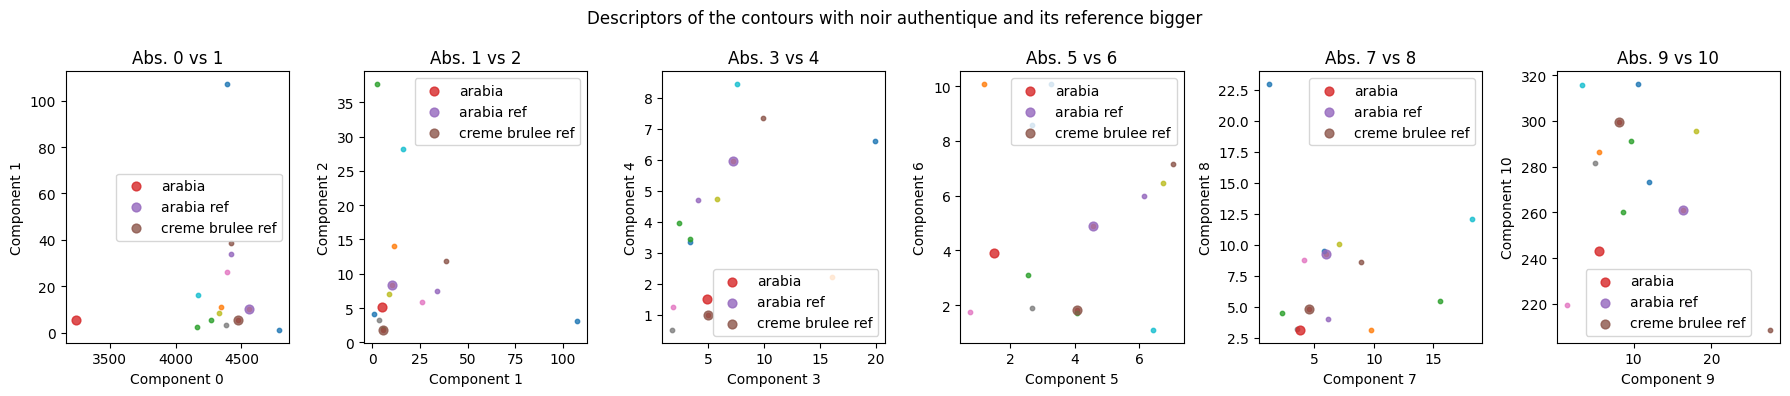

In [233]:
# Plot fourier descriptors with misinterpreted chocolate and arabia and creme brulee reference.
# Number of paris to display
n_features = descriptors_ref.shape[1]
# Define pairs for 2D plots
pairs = np.array(range(2*np.ceil(n_features / 2).astype(int)))
# Check if odd lenght, shift second feature to have pairs
if n_features % 2 == 1:
    pairs[2:] = pairs[1:-1]
# Convert to 2d array
pairs = pairs.reshape(-1, 2)

# Plot each pairs and labels
n_plots = len(pairs)
_ , axes = plt.subplots(1, n_plots, figsize=(18, 4))

for i, (pa, pb) in enumerate(pairs):
    # Abs
    for n in range(len(ref_choco)):
        axes[i].scatter(np.abs(descriptors_ref[n, pa]), np.abs(descriptors_ref[n, pb]), s=10, alpha=0.8)
    axes[i].scatter(np.abs(descriptors_object[2, pa]), np.abs(descriptors_object[2, pb]), s=40, alpha=0.8, label='arabia')
    axes[i].scatter(np.abs(descriptors_ref[1, pa]), np.abs(descriptors_ref[1, pb]), s=40, alpha=0.8, label='arabia ref')
    axes[i].scatter(np.abs(descriptors_ref[3, pa]), np.abs(descriptors_ref[3, pb]), s=40, alpha=0.8, label='creme brulee ref')
    axes[i].set_xlabel("Component {}".format(pa))
    axes[i].set_ylabel("Component {}".format(pb))
    axes[i].set_title("Abs. {} vs {}".format(pa, pb))
    axes[i].legend()

plt.suptitle("Descriptors of the contours with noir authentique and its reference bigger")
plt.tight_layout()

We easily see that for this fourier descriptor, the reference of creme brulee is unfortunately closest than arabia reference. This leads to a false negative in classification.

### Classification conclusion

In this classification, we try to use as many as possible features that we see in the course. By analysing many of them, we came up with an algorithm that use three very useful features. Theses three features together provide a very good classification when considering perfect masks. In our project, masks are not perfect and it leads to misinterpretation and consequently to false negatives and positives, which reduces accuracy.